In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data

In [6]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [7]:

def build_graph(sequence, score_map, distance_map=None):
    
    N = len(sequence)
    # Build fully-connected directed edges excluding self-loops
    src, dst = [], []
    edge_scores = []
    edge_sep = []
    edge_targets = []
    edge_mask = []

    score_map=np.log(np.array(score_map)+1)
    distance_map=np.log((np.array(distance_map)-15)/8+2)
    for i in range(N):
        for j in range(N):
            if i == j:
                continue

            src.append(i)
            dst.append(j)


            edge_scores.append(score_map[i, j])
            #edge_sep.append(abs(i - j))        ## feature suggerita da chat per capire se la distanza è effettivamente dovuta al fatto che gli ammino sono vicini nella catena o se sono molto interagenti. maybe normalize by sequence length?


            if distance_map is not None:
                # If unknown distance because of gaps, mask it out
                d = distance_map[i, j]
                known = not torch.isinf(torch.tensor(d))
                edge_mask.append(known)

                if known:
                    edge_targets.append(d)
                else:
                    edge_targets.append(0.0)   # dummy value, ignored by mask
            else:
                edge_mask.append(True)  # No masking if no distance map provided
                edge_targets.append(0.0)  # dummy value, can be ignored
    
    x = sinusoidal_positional_encoding(N, d_model=16)  # Node features: positional encodings
    #x = torch.ones((N, 1))  # Node features: one-hot encoding of node indices
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr = torch.tensor(edge_scores, dtype=torch.float).unsqueeze(-1)
    y = torch.tensor(edge_targets, dtype=torch.float).unsqueeze(-1)
    mask = torch.tensor(edge_mask, dtype=torch.bool)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        edge_mask=mask
    )

In [10]:
folder_path = "Data"

all_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']
        data = build_graph(sequence, contact_map_DCA, distance_map)
        all_data.append(data)

from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=17)


train_loader = DataLoader(train_data, batch_size=3, shuffle=True)
#train_loader = DataLoader([all_data[3]], batch_size=1)
test_loader = DataLoader(test_data, batch_size=3, shuffle=False)

#batch.batch[batch.edge_index[0]]


In [11]:
print(train_loader.dataset)

[Data(x=[599, 16], edge_index=[2, 358202], edge_attr=[358202, 1], y=[358202, 1], edge_mask=[358202]), Data(x=[39, 16], edge_index=[2, 1482], edge_attr=[1482, 1], y=[1482, 1], edge_mask=[1482]), Data(x=[77, 16], edge_index=[2, 5852], edge_attr=[5852, 1], y=[5852, 1], edge_mask=[5852]), Data(x=[53, 16], edge_index=[2, 2756], edge_attr=[2756, 1], y=[2756, 1], edge_mask=[2756]), Data(x=[93, 16], edge_index=[2, 8556], edge_attr=[8556, 1], y=[8556, 1], edge_mask=[8556]), Data(x=[81, 16], edge_index=[2, 6480], edge_attr=[6480, 1], y=[6480, 1], edge_mask=[6480]), Data(x=[195, 16], edge_index=[2, 37830], edge_attr=[37830, 1], y=[37830, 1], edge_mask=[37830]), Data(x=[65, 16], edge_index=[2, 4160], edge_attr=[4160, 1], y=[4160, 1], edge_mask=[4160]), Data(x=[299, 16], edge_index=[2, 89102], edge_attr=[89102, 1], y=[89102, 1], edge_mask=[89102]), Data(x=[77, 16], edge_index=[2, 5852], edge_attr=[5852, 1], y=[5852, 1], edge_mask=[5852]), Data(x=[76, 16], edge_index=[2, 5700], edge_attr=[5700, 1], 

In [12]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out

In [13]:
from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, edge_in_ch = 8, node_out_ch = 1, multipl_mid_layers = 2, edge_out_ch = 2, GNN_layers=4, node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None

        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
        if self.edge_norms is not None:
            self.edge_norms.append(LayerNorm(edge_in_ch))
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = edge_in_ch,
            node_out_ch = node_in_ch * multipl_mid_layers,
            edge_out_ch = edge_in_ch * multipl_mid_layers
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(edge_in_ch * multipl_mid_layers, edge_in_ch * multipl_mid_layers),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 2):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(node_in_ch * multipl_mid_layers))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(edge_in_ch * multipl_mid_layers))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=node_in_ch * multipl_mid_layers,
                edge_in_ch=edge_in_ch * multipl_mid_layers,
                node_out_ch=node_in_ch * multipl_mid_layers,
                edge_out_ch=edge_in_ch * multipl_mid_layers
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(edge_in_ch * multipl_mid_layers, edge_in_ch * multipl_mid_layers),
                nn.Sigmoid()
                ))

        # Final Intermediate layer
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch=node_in_ch * multipl_mid_layers,
            edge_in_ch=edge_in_ch * multipl_mid_layers,
            node_out_ch=node_out_ch,
            edge_out_ch=edge_out_ch
        ))

    def forward(self, graph):
        x, edge_index, edge_attr, batch = graph.x, graph.edge_index, graph.edge_attr, graph.batch

        edge_batch = batch[edge_index[0]]  # batch degli edge = batch del nodo sorgente

        for i, (node_norm, edge_norm, conv) in enumerate(zip(self.node_norms, self.edge_norms, self.convs[:-1])):
            x_in = x
            e_in = edge_attr
            x = node_norm(x, batch) if node_norm is not None else x
            edge_attr = edge_norm(edge_attr, edge_batch) if edge_norm is not None else edge_attr

            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in
            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr) if self.gating is not None else 1.0
                edge_attr = edge_attr * gate  # edge gating
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, negative_slope=0.2)
            edge_attr = F.leaky_relu(edge_attr, negative_slope=0.2)

            #x = self.dropout(x)
            #edge_attr = self.dropout(edge_attr)

        # Final projection to output space
        x, edge_attr = self.convs[-1](x, edge_index, edge_attr)

        return x, edge_attr

In [ ]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
#Create model
model = EdgeGNN(node_in_ch=16, edge_in_ch=1, edge_out_ch=1, GNN_layers=7)
model = model.to(device)
loss_fn = torch.nn.HuberLoss()  ##controllare parametri
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


train_losses = []
val_losses = []
for epoch in range(100): 

    model.train()
    train_loss = 0
    num_batches = 0

    for batch in train_loader:
        batch = batch.to(device) 
        

        # 3. Forward pass
        optimizer.zero_grad() 
        _, pred_dist = model(batch)

        # 4. Compute masked loss
        mask = batch.edge_mask
        true_dist = batch.y.squeeze(-1)
        pred_dist = pred_dist.squeeze(-1)

        loss = loss_fn(pred_dist[mask], true_dist[mask])

        # 5. Backpropagate
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        num_batches += 1

    train_loss /= num_batches
    train_losses.append(train_loss)
    

    # validation
    model.eval()
    val_loss = 0
    num_batches = 0

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)

            _, pred_dist = model(batch)

            mask = batch.edge_mask
            true_dist = batch.y.squeeze(-1)
            pred_dist = pred_dist.squeeze(-1)

            loss = loss_fn(pred_dist[mask], true_dist[mask])

            val_loss += loss.item()
            num_batches += 1

    val_loss /= num_batches
    val_losses.append(val_loss)

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")



Epoch 0: Train Loss=0.2247, Val Loss=0.1764
Epoch 1: Train Loss=0.2056, Val Loss=0.1756
Epoch 2: Train Loss=nan, Val Loss=0.1720
Epoch 3: Train Loss=0.1971, Val Loss=0.1968
Epoch 4: Train Loss=nan, Val Loss=0.1633
Epoch 5: Train Loss=0.1788, Val Loss=0.1577
Epoch 6: Train Loss=0.1774, Val Loss=0.1562
Epoch 7: Train Loss=0.1704, Val Loss=0.1521
Epoch 8: Train Loss=0.1699, Val Loss=0.1540
Epoch 9: Train Loss=0.1744, Val Loss=0.1706
Epoch 10: Train Loss=0.1742, Val Loss=0.1743
Epoch 11: Train Loss=nan, Val Loss=0.1573
Epoch 12: Train Loss=nan, Val Loss=0.1532
Epoch 13: Train Loss=0.2230, Val Loss=0.1574
Epoch 14: Train Loss=0.1771, Val Loss=0.1609
Epoch 15: Train Loss=0.1802, Val Loss=0.1603
Epoch 16: Train Loss=nan, Val Loss=0.1621
Epoch 17: Train Loss=0.1686, Val Loss=0.1536
Epoch 18: Train Loss=nan, Val Loss=0.1544
Epoch 19: Train Loss=0.1725, Val Loss=0.1486
Epoch 20: Train Loss=nan, Val Loss=0.1511
Epoch 21: Train Loss=0.1737, Val Loss=0.1480
Epoch 22: Train Loss=0.1594, Val Loss=0.1

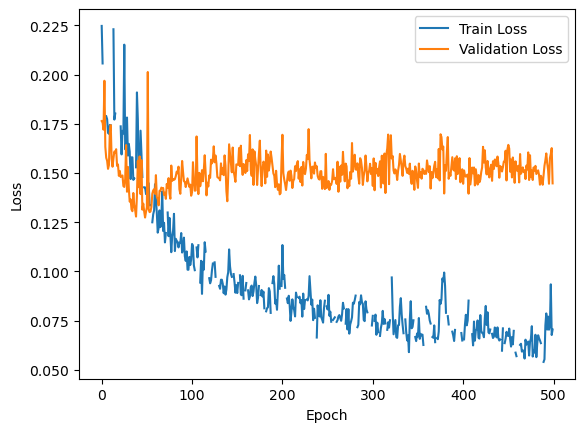

In [24]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [16]:
def graph_to_matrix(data, values):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

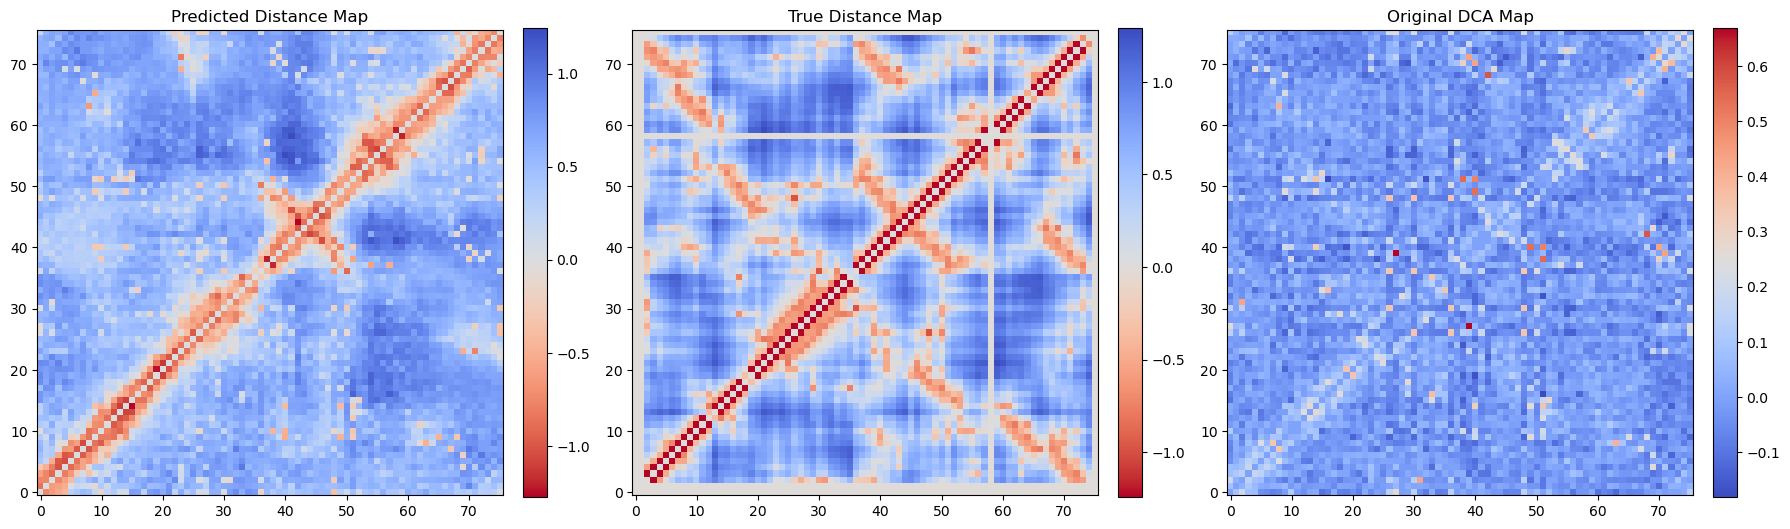

In [27]:
loader = DataLoader([train_loader.dataset[10]], batch_size=1)
#loader = DataLoader([test_data[3]], batch_size=1)
batch = next(iter(loader)).to(device)

with torch.no_grad():
    _, pred_dist = model(batch)

pred_dist = pred_dist.squeeze()

pred_dist_map = graph_to_matrix(batch, pred_dist.cpu())
true_dist_map = graph_to_matrix(batch, batch.y.cpu())
original_dca_map = graph_to_matrix(batch, batch.edge_attr.cpu())


fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_dist_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Distance Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_dist_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Distance Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original DCA Map ---
im2 = axes[2].imshow(original_dca_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Original DCA Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()